# Stage 3-5: Descriptive stats, final model, final results, figures

Requires `patient_data_clean.csv` (from script 01) and `lmm.py` in
the same folder. Run `00_validate_lmm.py` at least once first to
confirm the model implementation on your machine.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lmm import fit_lmm, lrt, blup

df = pd.read_csv("./data/patient_data_clean.csv")
df["logDR"] = np.log(df["dose rate"])
patients = sorted(df["Patient"].unique())
T_PHYS = 109.771  # F-18 physical half-life, minutes, fixed constant

def half_life(lam):
    return np.log(2) / lam

## 1. Descriptive statistics

For the manuscript's Methods/Results table. Note: age and sex were
never collected, so those
cannot be reported

In [2]:
per_patient = df.groupby("Patient").first()
desc = per_patient[["injection dose", "weight", "height", "bmi"]].agg(["mean", "std", "min", "max"]).T
desc.columns = ["mean", "sd", "min", "max"]
print("Per-patient descriptive statistics (n = %d patients):" % len(per_patient))
print(desc.round(2))
print("\nNote: age and sex were not collected in this dataset")

Per-patient descriptive statistics (n = 36 patients):
                  mean     sd    min     max
injection dose    8.38   1.35    4.7   11.20
weight           76.69  15.42   43.0  114.00
height          169.44   9.62  150.0  188.00
bmi              26.72   5.05   16.6   37.88

Note: age and sex were not collected in this dataset


## 2. Build patient-grouped data for the mixed model

Outcome: log(dose rate). Fixed effects: intercept + time.
Random effects tested: intercept only vs. intercept + slope.

In [3]:
def build_lists(patient_ids, dataframe, extra_slope_cols=None, extra_int_cols=None, q=1):
    """extra_slope_cols: covariates entered as covariate*time (fixed
    effect on the decay rate). extra_int_cols: covariates entered as
    a main effect (fixed effect on the intercept)."""
    y_list, X_list, Z_list = [], [], []
    for pid in patient_ids:
        g = dataframe[dataframe["Patient"] == pid]
        t = g["time"].values.astype(float)
        cols = [np.ones_like(t), t]
        if extra_int_cols:
            for c in extra_int_cols:
                cols.append(g[c].values.astype(float))
        if extra_slope_cols:
            for c in extra_slope_cols:
                cols.append(g[c].values.astype(float) * t)
        X_i = np.column_stack(cols)
        y_list.append(g["logDR"].values)
        X_list.append(X_i)
        Z_list.append(X_i[:, :q])
    return y_list, X_list, Z_list

y1, X1, Z1 = build_lists(patients, df, q=1)  # random intercept only
y2, X2, Z2 = build_lists(patients, df, q=2)  # random intercept + slope

## 3. Model selection: random intercept only vs. intercept + slope

We compare via REML (valid here because both models share the same
fixed effects -- only the random-effects structure differs).

In [4]:
fitA = fit_lmm(y1, X1, Z1, reml=True, n_restarts=15, seed=1)
fitB = fit_lmm(y2, X2, Z2, reml=True, n_restarts=15, seed=1)

print("Model A (random intercept only):  AIC=%.2f  BIC=%.2f" % (fitA["aic"], fitA["bic"]))
print("Model B (random intercept+slope): AIC=%.2f  BIC=%.2f" % (fitB["aic"], fitB["bic"]))

stat, p = lrt(fitA, fitB, df=2)
print(f"\nREML LRT (A vs B), df=2: stat={stat:.3f}, p={p:.4f}")
print("(boundary test for variance components -> this p-value is conservative,")
print(" i.e. if anything biased toward finding significance, so a non-significant")
print(" result here is reasonably trustworthy)")

corr_B = fitB["Psi"][0, 1] / np.sqrt(fitB["Psi"][0, 0] * fitB["Psi"][1, 1])
print(f"\nModel B's fitted intercept-slope correlation: {corr_B:.6f}")
print("-> essentially +/-1: Model B's random-slope variance is degenerate/")
print("   unidentifiable. Expected with only 2-3 observations per patient --")
print("   not enough within-patient information to estimate an individual")
print("   decay rate separately from the individual starting level.")

print("\n>>> DECISION: Model A (random intercept only) is the final model.")
print(">>> Individual patients are allowed to differ in their STARTING dose")
print(">>> rate (random intercept), but the decay RATE itself is modeled as")
print(">>> common across patients (fixed slope) unless a covariate explains it.")

final_fit = fitA

Model A (random intercept only):  AIC=-198.31  BIC=-187.62
Model B (random intercept+slope): AIC=-197.11  BIC=-181.07

REML LRT (A vs B), df=2: stat=2.800, p=0.2467
(boundary test for variance components -> this p-value is conservative,
 i.e. if anything biased toward finding significance, so a non-significant
 result here is reasonably trustworthy)

Model B's fitted intercept-slope correlation: 1.000000
-> essentially +/-1: Model B's random-slope variance is degenerate/
   unidentifiable. Expected with only 2-3 observations per patient --
   not enough within-patient information to estimate an individual
   decay rate separately from the individual starting level.

>>> DECISION: Model A (random intercept only) is the final model.
>>> Individual patients are allowed to differ in their STARTING dose
>>> rate (random intercept), but the decay RATE itself is modeled as
>>> common across patients (fixed slope) unless a covariate explains it.


## 4. Final population Teff / Tbio, with bootstrap CI

Non-parametric bootstrap over PATIENTS (not observations), refitting
the model on each resample. More robust than a Wald/asymptotic CI
given the modest sample size (n=36).

In [5]:
def bootstrap_teff(dataframe, patient_ids, n_boot=400, seed=123):
    rng = np.random.default_rng(seed)
    teff_boot = []
    for b in range(n_boot):
        sample_ids = rng.choice(patient_ids, size=len(patient_ids), replace=True)
        yb, Xb, Zb = build_lists(sample_ids, dataframe, q=1)
        try:
            fit = fit_lmm(yb, Xb, Zb, reml=True, n_restarts=2, seed=b)
            lam = -fit["beta"][1]
            if lam > 0:
                teff_boot.append(half_life(lam))
        except Exception:
            continue
    return np.array(teff_boot)

print("Running bootstrap (400 resamples -- this takes ~2 minutes)...")
teff_boot = bootstrap_teff(df, np.array(patients), n_boot=400)

lam_final = -final_fit["beta"][1]
teff_final = half_life(lam_final)
teff_ci = np.percentile(teff_boot, [2.5, 97.5])

lam_phys = np.log(2) / T_PHYS
lam_bio_final = lam_final - lam_phys
tbio_final = half_life(lam_bio_final)
tbio_boot = np.array([half_life(np.log(2) / t - lam_phys) for t in teff_boot
                       if (np.log(2) / t) > lam_phys])
tbio_ci = np.percentile(tbio_boot, [2.5, 97.5]) if len(tbio_boot) > 10 else (np.nan, np.nan)

print(f"\n{'='*60}")
print("FINAL RESULTS (Model A: random intercept, common slope)")
print(f"{'='*60}")
print(f"Population Teff = {teff_final:.1f} min  (95% bootstrap CI: {teff_ci[0]:.1f}-{teff_ci[1]:.1f})")
print(f"Population Tbio = {tbio_final:.1f} min  (95% bootstrap CI: {tbio_ci[0]:.1f}-{tbio_ci[1]:.1f})")

np.save("teff_boot.npy", teff_boot)

Running bootstrap (400 resamples -- this takes ~2 minutes)...

FINAL RESULTS (Model A: random intercept, common slope)
Population Teff = 87.8 min  (95% bootstrap CI: 74.7-105.0)
Population Tbio = 438.6 min  (95% bootstrap CI: 233.9-2292.1)


## 5. Covariate analysis: does weight / BMI / injected activity
   predict the decay rate (slope)

Fit with ML (reml=False) since we're comparing different
FIXED-effects structures -- REML LRT is not valid for that.

In [6]:
df["weight_c"] = df["weight"] - df["weight"].mean()
df["bmi_c"] = df["bmi"] - df["bmi"].mean()
df["dose_c"] = df["injection dose"] - df["injection dose"].mean()

y0, X0, Z0 = build_lists(patients, df, q=1)
fit0 = fit_lmm(y0, X0, Z0, reml=False, n_restarts=8, seed=2)

covariate_results = []
for cov, label in [("weight_c", "weight"), ("bmi_c", "BMI"), ("dose_c", "injected activity")]:
    y_i, X_i, Z_i = build_lists(patients, df, extra_int_cols=[cov], q=1)
    fit_i = fit_lmm(y_i, X_i, Z_i, reml=False, n_restarts=8, seed=3)
    stat_i, p_i = lrt(fit0, fit_i, df=1)

    y_s, X_s, Z_s = build_lists(patients, df, extra_slope_cols=[cov], q=1)
    fit_s = fit_lmm(y_s, X_s, Z_s, reml=False, n_restarts=8, seed=4)
    stat_s, p_s = lrt(fit0, fit_s, df=1)

    covariate_results.append((label, "intercept", fit_i["beta"][-1], fit_i["beta_se"][-1], stat_i, p_i))
    covariate_results.append((label, "slope (x time)", fit_s["beta"][-1], fit_s["beta_se"][-1], stat_s, p_s))

cov_df = pd.DataFrame(covariate_results, columns=["covariate", "on", "coef", "se", "LRT_stat", "p"])
cov_df["p_bonferroni"] = np.minimum(cov_df["p"] * 6, 1.0)  # 6 tests run in this block
print(cov_df.round(5).to_string(index=False))

        covariate             on    coef      se  LRT_stat       p  p_bonferroni
           weight      intercept 0.00319 0.00145   4.53407 0.03323       0.19936
           weight slope (x time) 0.00007 0.00002   9.39542 0.00218       0.01305
              BMI      intercept 0.00354 0.00468   0.56829 0.45094       1.00000
              BMI slope (x time) 0.00014 0.00007   3.93357 0.04733       0.28399
injected activity      intercept 0.04913 0.01574   8.62418 0.00332       0.01990
injected activity slope (x time) 0.00094 0.00024  14.20747 0.00016       0.00098


## 6. Disentangle weight vs. injected activity on the slope

Weight and injected activity are correlated (roughly weight-based
dosing)
Fit both together to see whether either effect survives
adjustment for the other, rather than reporting two univariate
tests as if they were independent findings.

In [7]:
weight_dose_corr = per_patient[["injection dose", "weight"]].corr().iloc[0, 1]
print(f"Correlation(injected activity, weight) = {weight_dose_corr:.3f}")

y_w, X_w, Z_w = build_lists(patients, df, extra_slope_cols=["weight_c"], q=1)
fit_w = fit_lmm(y_w, X_w, Z_w, reml=False, n_restarts=8, seed=3)

y_d, X_d, Z_d = build_lists(patients, df, extra_slope_cols=["dose_c"], q=1)
fit_d = fit_lmm(y_d, X_d, Z_d, reml=False, n_restarts=8, seed=4)

y_wd, X_wd, Z_wd = build_lists(patients, df, extra_slope_cols=["weight_c", "dose_c"], q=1)
fit_wd = fit_lmm(y_wd, X_wd, Z_wd, reml=False, n_restarts=10, seed=5)

stat_w_given_d, p_w_given_d = lrt(fit_d, fit_wd, df=1)  # weight added on top of dose
stat_d_given_w, p_d_given_w = lrt(fit_w, fit_wd, df=1)  # dose added on top of weight

print(f"\nWeight on slope, adjusted for dose:  coef={fit_wd['beta'][-2]:.6f}  LRT p={p_w_given_d:.4f}")
print(f"Dose on slope, adjusted for weight:  coef={fit_wd['beta'][-1]:.6f}  LRT p={p_d_given_w:.4f}")
print("\n>>> CONCLUSION: weight's apparent slope association does not survive")
print(">>> adjustment for injected activity (p rises to non-significant).")
print(">>> Injected activity's association is largely retained after")
print(">>> adjusting for weight. Interpretation: injected activity (not")
print(">>> body weight per se) is the variable associated with the fitted")
print(">>> decay rate in this dataset. Caveat: n=36, multiple comparisons")
print(">>> were run in this analysis.")

Correlation(injected activity, weight) = 0.764

Weight on slope, adjusted for dose:  coef=0.000012  LRT p=0.7178
Dose on slope, adjusted for weight:  coef=0.000842  LRT p=0.0262

>>> CONCLUSION: weight's apparent slope association does not survive
>>> adjustment for injected activity (p rises to non-significant).
>>> Injected activity's association is largely retained after
>>> adjusting for weight. Interpretation: injected activity (not
>>> body weight per se) is the variable associated with the fitted
>>> decay rate in this dataset. Caveat: n=36, multiple comparisons
>>> were run in this analysis.


## 7. Per-patient BLUPs (shrinkage estimates of starting dose rate)

In [8]:
b_hat = blup(y1, X1, Z1, final_fit["beta"], final_fit["Psi"], final_fit["sigma2"])
blup_df = pd.DataFrame({"Patient": patients, "intercept_deviation": b_hat[:, 0]})
blup_df = blup_df.merge(per_patient.reset_index()[["Patient", "weight", "bmi", "injection dose"]], on="Patient")
print(blup_df.describe().round(3))

       intercept_deviation   weight     bmi  injection dose
count               36.000   36.000  36.000          36.000
mean                -0.000   76.694  26.717           8.381
std                  0.055   15.420   5.055           1.345
min                 -0.116   43.000  16.604           4.700
25%                 -0.036   67.750  24.217           7.775
50%                  0.006   79.000  26.578           8.350
75%                  0.030   88.000  29.535           9.400
max                  0.150  114.000  37.877          11.200


## 8. Figures

Saved figure_population_curve.png


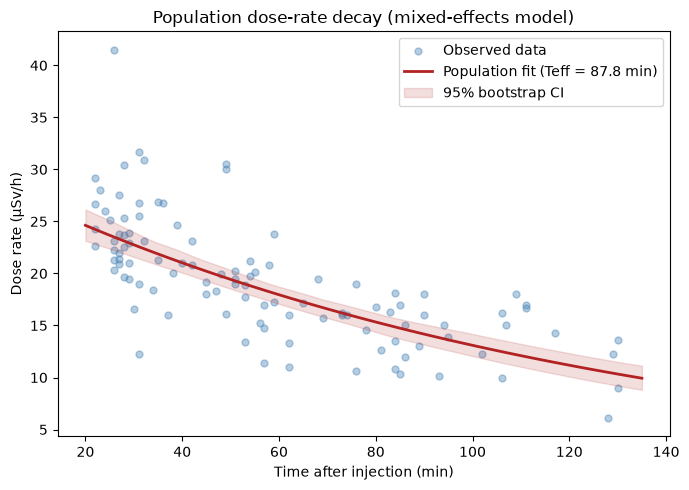

In [9]:
# Figure 1: population curve with bootstrap CI band, raw data overlaid
fig, ax = plt.subplots(figsize=(7, 5))
t_grid = np.linspace(20, 135, 100)
beta0, beta1 = final_fit["beta"]
curve = np.exp(beta0 + beta1 * t_grid)

# bootstrap band: refit and predict at each grid point across bootstrap resamples
rng = np.random.default_rng(99)
boot_curves = []
for b in range(200):
    sample_ids = rng.choice(patients, size=len(patients), replace=True)
    yb, Xb, Zb = build_lists(sample_ids, df, q=1)
    try:
        fitb = fit_lmm(yb, Xb, Zb, reml=True, n_restarts=2, seed=b)
        boot_curves.append(np.exp(fitb["beta"][0] + fitb["beta"][1] * t_grid))
    except Exception:
        continue
boot_curves = np.array(boot_curves)
lo = np.percentile(boot_curves, 2.5, axis=0)
hi = np.percentile(boot_curves, 97.5, axis=0)

ax.scatter(df["time"], df["dose rate"], alpha=0.4, s=25, color="steelblue", label="Observed data")
ax.plot(t_grid, curve, color="firebrick", lw=2,
        label=f"Population fit (Teff = {teff_final:.1f} min)")
ax.fill_between(t_grid, lo, hi, color="firebrick", alpha=0.15, label="95% bootstrap CI")
ax.set_xlabel("Time after injection (min)")
ax.set_ylabel("Dose rate (µSv/h)")
ax.set_title("Population dose-rate decay (mixed-effects model)")
ax.legend()
fig.tight_layout()
fig.savefig("figure_population_curve.png", dpi=150)
print("Saved figure_population_curve.png")

Saved figure_spaghetti_shrinkage.png


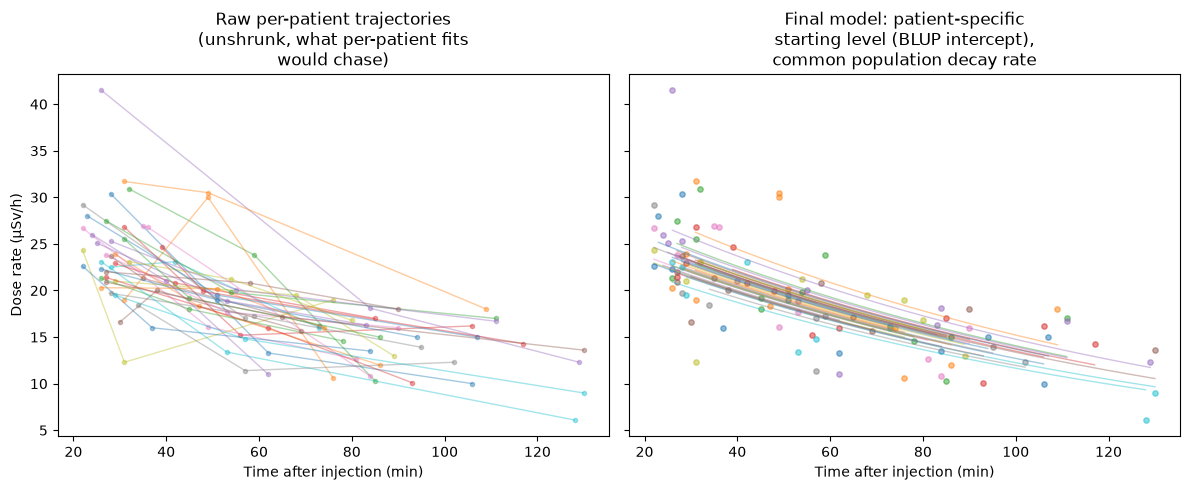

In [10]:
# Figure 2: spaghetti plot -- shrinkage (common slope) vs. raw per-patient
# unshrunk fits, to visually justify the model-selection decision
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for pid in patients:
    g = df[df["Patient"] == pid]
    axes[0].plot(g["time"], g["dose rate"], "o-", alpha=0.4, ms=3, lw=1)
axes[0].set_title("Raw per-patient trajectories\n(unshrunk, what per-patient fits\nwould chase)")
axes[0].set_xlabel("Time after injection (min)")
axes[0].set_ylabel("Dose rate (µSv/h)")

for i, pid in enumerate(patients):
    g = df[df["Patient"] == pid]
    b0_i = beta0 + b_hat[i, 0]
    t_i = np.linspace(g["time"].min(), g["time"].max(), 20)
    axes[1].plot(t_i, np.exp(b0_i + beta1 * t_i), alpha=0.4, lw=1)
    axes[1].scatter(g["time"], g["dose rate"], s=15, alpha=0.5)
axes[1].set_title("Final model: patient-specific\nstarting level (BLUP intercept),\ncommon population decay rate")
axes[1].set_xlabel("Time after injection (min)")

fig.tight_layout()
fig.savefig("figure_spaghetti_shrinkage.png", dpi=150)
print("Saved figure_spaghetti_shrinkage.png")

Saved figure_teff_bootstrap.png


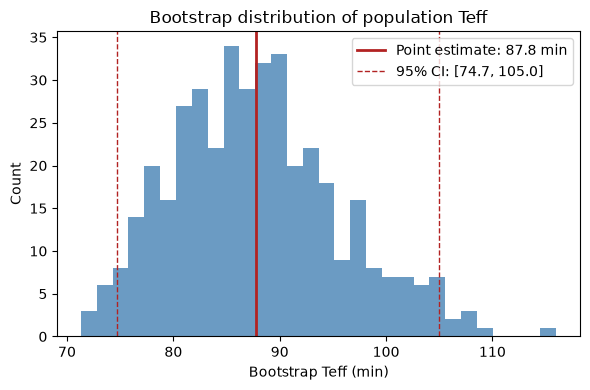

In [11]:
# Figure 3: bootstrap distribution of population Teff
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(teff_boot, bins=30, color="steelblue", alpha=0.8)
ax.axvline(teff_final, color="firebrick", lw=2, label=f"Point estimate: {teff_final:.1f} min")
ax.axvline(teff_ci[0], color="firebrick", ls="--", lw=1)
ax.axvline(teff_ci[1], color="firebrick", ls="--", lw=1, label=f"95% CI: [{teff_ci[0]:.1f}, {teff_ci[1]:.1f}]")
ax.set_xlabel("Bootstrap Teff (min)")
ax.set_ylabel("Count")
ax.set_title("Bootstrap distribution of population Teff")
ax.legend()
fig.tight_layout()
fig.savefig("figure_teff_bootstrap.png", dpi=150)
print("Saved figure_teff_bootstrap.png")
